# Risk, returns, and preferences

Three of the library's more advanced capabilities: **multiple endogenous
states** (a liquid + an illiquid asset), **Epstein–Zin** preferences that
separate risk aversion from the intertemporal elasticity, and the **endogenous
grid method (EGM)** as a fast, accurate alternative solver. We solve a
two-asset portfolio problem, raise risk aversion under Epstein–Zin holding the
elasticity fixed, and show that EGM and value-function iteration recover the
same consumption policy. All with `puremacro.vfi`, in the browser.

## The method in three pieces

**Two-asset budget.** Households hold a liquid asset $m$ (freely adjustable,
low return $r_m$) and an illiquid asset $k$ (higher return $r_k>r_m$, but
rebalancing costs $\kappa\,|k'-k|$ per unit moved). With AR(1) income $e^{z}$
(Tauchen-discretized) and no borrowing, consumption is
$$ c = (1+r_m)\,m + (1+r_k)\,k + e^{z} - m' - k' - \kappa\,|k'-k|,\qquad m',k'\ge 0. $$
The state is the *pair* $(m,k)$ — two continuous endogenous states optimized jointly.

**Epstein–Zin recursive utility.** Time-separable CRRA ties risk aversion to
the inverse elasticity of intertemporal substitution (EIS). Epstein–Zin breaks
that link, with risk aversion $\gamma$ and EIS $\psi$ as separate parameters:
$$ V = \Big[(1-\beta)\,u^{\rho} + \beta\,\big(\mathbb{E}_t[\,V'^{\,1-\gamma}\,]\big)^{\rho/(1-\gamma)}\Big]^{1/\rho},
\qquad \rho = 1-\tfrac{1}{\psi}. $$
The inner term is the **certainty equivalent** $\mathrm{CE}=(\mathbb{E}_t[V'^{\,1-\gamma}])^{1/(1-\gamma)}$:
next period's random value is collapsed to a riskless equivalent through the
risk-aversion curvature $\gamma$, then traded off against today through the EIS
curvature $\rho$. When $\gamma=1/\psi$ (i.e. $\rho=1-\gamma$) the recursion
collapses back to time-separable expected utility.

**Endogenous grid method (EGM).** For the one-asset CRRA problem the optimal
policy satisfies the Euler equation $c^{-\gamma}=\beta(1+r)\,\mathbb{E}_t[c'^{-\gamma}]$.
Rather than searching for $a'$ at each state, EGM *fixes* a grid of next-period
assets, evaluates the right-hand side, and inverts to read off today's
consumption $c=\big(\beta(1+r)\,\mathbb{E}_t[c'^{-\gamma}]\big)^{-1/\gamma}$ and the
endogenous current assets that justify it — no root-finding, $O(n)$ per
iteration, and a continuous (interpolated) policy.

**Intuition.** Separating $\gamma$ from $\psi$ matters because risk and time
are distinct: $\gamma$ governs how much a household dislikes a *gamble* over
next period's value, while $\psi$ governs how willingly it *shifts* consumption
across dates. Hold $\psi$ fixed and raise $\gamma$ and you strengthen the
precautionary motive alone — households save more for the *same* willingness to
substitute over time, which a single CRRA parameter cannot express. EGM is fast
because it never optimizes per state: it exploits the monotone Euler equation to
invert the policy directly. And the two-asset split is a risk–return tradeoff —
the illiquid asset's return premium is paid for with adjustment frictions, so
liquid balances are the buffer that absorbs income risk.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.vfi import (
    two_asset_profile, EpsteinZinProblem, solve_egm, VFIProblem,
    tauchen, markov_stationary, stationary_distribution,
)

## 1. Two assets: a liquid buffer and an illiquid store of value
Liquid `m` is freely adjustable but low-return; illiquid `k` pays a higher
return but costs to rebalance. Solving over the joint `(m, k)` grid is a
**multiple-endogenous-state** problem — two continuous assets optimized at once.

In [2]:
ta = two_asset_profile(n_m=18, n_k=20, n_z=5, r_illiquid=0.03, k_max=25.0)
print(f"E[liquid]={ta['mean_liquid']:.2f}, E[illiquid]={ta['mean_illiquid']:.2f}, "
      f"illiquid share={ta['illiquid_share']:.2f}, wealth Gini={ta['wealth_gini']:.2f}")
assert 0.0 < ta["illiquid_share"] < 1.0
assert 0.0 < ta["wealth_gini"] < 1.0

n_m, n_k = 18, 20
m_grid = np.linspace(0.0, 15.0, n_m)
k_grid = np.linspace(0.0, 25.0, n_k)
mk = ta["distribution"].sum(axis=1).reshape(n_m, n_k)     # joint (m,k) mass, marginal over income

E[liquid]=1.37, E[illiquid]=15.61, illiquid share=0.92, wealth Gini=0.34


### Hero figure — the joint portfolio distribution
Households concentrate wealth in the higher-return illiquid asset `k`, holding
a smaller liquid balance `m` as a buffer against income risk. The cross marks
mean holdings — the optimal split the engine finds over two endogenous states.

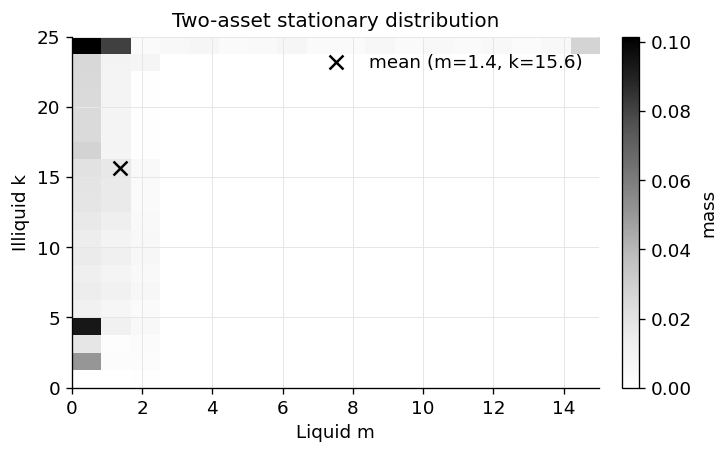

In [3]:
fig, ax = plt.subplots()
im = ax.imshow(mk.T, origin="lower", aspect="auto", cmap="Greys",
               extent=[m_grid[0], m_grid[-1], k_grid[0], k_grid[-1]])
ax.scatter([ta["mean_liquid"]], [ta["mean_illiquid"]], color="0.0", marker="x", s=70,
           label=f"mean (m={ta['mean_liquid']:.1f}, k={ta['mean_illiquid']:.1f})")
ax.set_xlabel("Liquid m"); ax.set_ylabel("Illiquid k")
ax.set_title("Two-asset stationary distribution")
ax.legend(loc="upper right")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="mass")
plt.show()

**Read the output.** The illiquid share printed above (mass in $k$ as a fraction
of total wealth) is well above one-half: households park most of their wealth in
the higher-return illiquid asset and keep only a thin liquid balance $m$. That
liquid sliver is *precautionary* — it lets them smooth income shocks without
paying the adjustment cost $\kappa$ to touch $k$. The wealth Gini, strictly
between 0 and 1, confirms a genuinely dispersed distribution over the joint
$(m,k)$ grid: the cross in the figure marks mean holdings, and the mass leans
toward high $k$, low $m$, exactly the corner the return premium rewards.

## 2. Epstein–Zin: risk aversion vs. the elasticity of substitution
Time-separable CRRA forces risk aversion = 1/EIS. Epstein–Zin separates them.
Holding the EIS fixed and raising risk aversion strengthens the precautionary
motive, so households save more.

mean assets: risk aversion 2 → 0.07, risk aversion 8 → 0.22


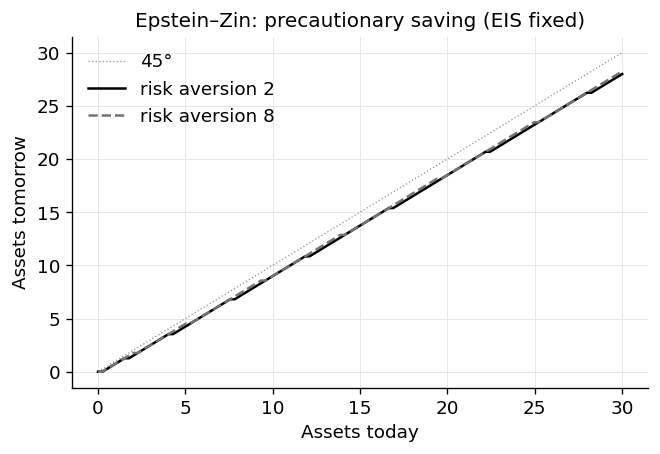

In [4]:
z_g, Pz = tauchen(n=5, rho=0.9, sigma=0.2)
a_g = np.linspace(0.01, 30.0, 120)
psi = 1.5                                                 # EIS (fixed)

def ez_mean_assets(gamma):
    def felicity(ap, a, z, xp=np):                        # period felicity must be > 0
        c = 1.0 + 0.5 * xp.exp(z) + 1.03 * a - ap
        return xp.where(c > 0.0, c, -np.inf)
    sol = EpsteinZinProblem(a_grid=a_g, z_grid=z_g, P_z=Pz, return_fn=felicity,
                            beta=0.95, gamma=gamma, psi=psi).solve()
    mu = stationary_distribution(sol.policy_aprime, Pz)
    return float(np.sum(mu * a_g[:, None])), a_g[sol.policy_aprime]

mean_lo, pol_lo = ez_mean_assets(2.0)
mean_hi, pol_hi = ez_mean_assets(8.0)
print(f"mean assets: risk aversion 2 → {mean_lo:.2f}, risk aversion 8 → {mean_hi:.2f}")
assert mean_hi > mean_lo                                  # more risk aversion → more saving

mid = len(z_g) // 2
fig, ax = plt.subplots()
ax.plot(a_g, a_g, color="0.6", linewidth=0.8, linestyle=":", label="45°")
ax.plot(a_g, pol_lo[:, mid], color=_nbstyle.palette(2)[0], label="risk aversion 2")
ax.plot(a_g, pol_hi[:, mid], color=_nbstyle.palette(2)[1], linestyle="--",
        label="risk aversion 8")
ax.set_xlabel("Assets today"); ax.set_ylabel("Assets tomorrow")
ax.set_title("Epstein–Zin: precautionary saving (EIS fixed)"); ax.legend(loc="upper left")
plt.show()

**Read the output.** With the EIS held at $\psi=1.5$, the only thing that
changed between the two solves is risk aversion ($\gamma=2$ vs. $\gamma=8$), yet
mean assets rise — a pure precautionary effect that a single CRRA parameter
could not isolate, since raising CRRA would have moved the EIS too. In the
figure the $\gamma=8$ saving policy sits *above* the $\gamma=2$ policy and
further above the 45° line: at every level of assets the more risk-averse
household carries more wealth into next period as self-insurance against the
AR(1) income shock.

## 3. EGM vs. VFI: same answer, different solver
The endogenous grid method inverts the Euler equation (continuous policy, O(n)
per iteration). It matches the discretized value-function-iteration consumption
policy closely.

max |c_EGM − c_VFI| at median income = 0.152


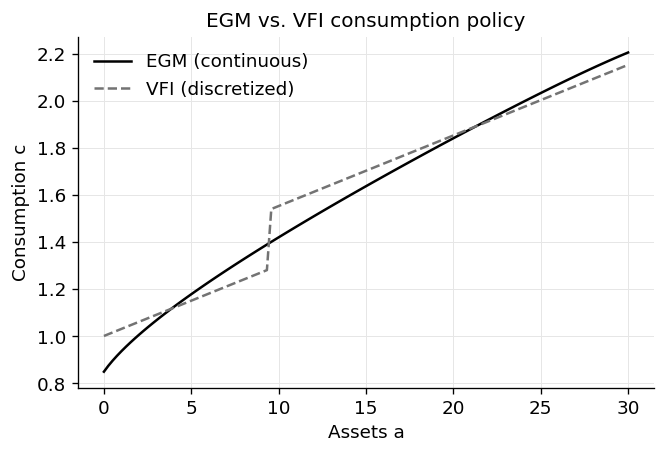

In [5]:
gamma, r, beta = 2.0, 0.03, 0.96
income = np.exp(z_g)
egm = solve_egm(a_g, z_g, income, Pz, beta=beta, r=r, gamma=gamma)

def util(c, xp):
    cc = xp.maximum(c, 1e-12)
    return (cc ** (1.0 - gamma) - 1.0) / (1.0 - gamma)

def rf(ap, a, z, xp=np):
    c = (1.0 + r) * a + xp.exp(z) - ap
    return xp.where(c > 0.0, util(c, xp), -np.inf)

vsol = VFIProblem(a_grid=a_g, z_grid=z_g, P_z=Pz, return_fn=rf, beta=beta,
                  options=dict(tol=1e-9, n_howard=40)).solve()
c_vfi = (1.0 + r) * a_g[:, None] + income[None, :] - a_g[vsol.policy_aprime]
max_gap = float(np.max(np.abs(c_vfi[:, mid] - egm.c[:, mid])))
print(f"max |c_EGM − c_VFI| at median income = {max_gap:.3f}")
assert max_gap < 0.5                                      # close (VFI is grid-discretized)

fig, ax = plt.subplots()
ax.plot(a_g, egm.c[:, mid], color="0.0", label="EGM (continuous)")
ax.plot(a_g, c_vfi[:, mid], color="0.45", linestyle="--", label="VFI (discretized)")
ax.set_xlabel("Assets a"); ax.set_ylabel("Consumption c")
ax.set_title("EGM vs. VFI consumption policy"); ax.legend(loc="upper left")
plt.show()

**Read the output.** The maximum gap between the EGM and VFI consumption
policies (printed above) is a small fraction of consumption — the two solvers
agree. The residual is not error in EGM but *discretization* in VFI: EGM's
policy is continuous (it interpolates off the inverted Euler equation), while
VFI must pick $a'$ from the 120-node grid, so its consumption is piecewise-flat
and the two diverge most where the grid is coarse relative to the policy's
slope. In the figure the solid EGM curve threads smoothly through the stair-step
VFI curve. Same economics, two algorithms — and EGM gets there in $O(n)$ per
iteration with no per-state optimization.

## Your turn — does EGM still match VFI when you change preferences?

Section 3 used `gamma = 2`. Crank up risk aversion (a more curved utility, a
stiffer Euler equation) and check two structural facts that should survive *any*
reasonable choice: (i) the EGM and VFI consumption policies still agree to a
tolerance, and (ii) the EGM policy is monotone in wealth (consume more when you
have more). We hold the return `r` and `beta` fixed at the section-3 values so
this stays a cheap one-asset re-solve. Change `gamma_you`.

Tip: keep `gamma_you` well above 0 (CRRA needs $\gamma>0$). Very large values
(say 20+) flatten the consumption policy as precaution dominates, but EGM and
VFI still track each other — the agreement is about the *solvers*, not the
parameter.

In [6]:
# ← Change this risk-aversion parameter (CRRA curvature). Keep it > 0.
gamma_you = 5.0

egm_you = solve_egm(a_g, z_g, income, Pz, beta=beta, r=r, gamma=gamma_you)

def util_you(c, xp):
    cc = xp.maximum(c, 1e-12)
    return (cc ** (1.0 - gamma_you) - 1.0) / (1.0 - gamma_you)

def rf_you(ap, a, z, xp=np):
    c = (1.0 + r) * a + xp.exp(z) - ap
    return xp.where(c > 0.0, util_you(c, xp), -np.inf)

vsol_you = VFIProblem(a_grid=a_g, z_grid=z_g, P_z=Pz, return_fn=rf_you, beta=beta,
                      options=dict(tol=1e-9, n_howard=40)).solve()
c_vfi_you = (1.0 + r) * a_g[:, None] + income[None, :] - a_g[vsol_you.policy_aprime]
gap_you = float(np.max(np.abs(c_vfi_you[:, mid] - egm_you.c[:, mid])))
min_slope = float(np.min(np.diff(egm_you.c[:, mid])))     # monotone consumption ⇒ ≥ 0
print(f"gamma={gamma_you}: max |c_EGM − c_VFI| = {gap_you:.3f}, "
      f"min Δc (EGM, over wealth) = {min_slope:+.4f}")
assert gap_you < 0.5                                       # solvers agree (VFI is grid-discretized)
assert min_slope >= -1e-9                                  # EGM consumption rises with wealth

gamma=5.0: max |c_EGM − c_VFI| = 0.159, min Δc (EGM, over wealth) = +0.0039


**Prompts.** (1) Set `gamma_you = 1.5` and `gamma_you = 10.0`; the gap stays
small both times — confirm EGM and VFI agree regardless of curvature. (2) At
high `gamma_you` the EGM consumption policy flattens (precaution dominates):
compare `egm_you.c[:, mid]` at the bottom vs. top of `a_g` for `gamma=2` and
`gamma=10`. (3) *Stretch:* read `egm_you.n_iter` for a few `gamma_you` — it *rises*
with curvature (the fixed point stiffens), yet each iteration stays $O(n)$ in the grid
(no per-state root-finding), which is EGM's real speed advantage.

**How comprehensive is this?** `puremacro.vfi` is a full heterogeneous-agent
toolkit, and EGM, Epstein–Zin, and multiple endogenous states are all
first-class members of the same engine. The other showcase notebooks build on
it: **Aiyagari / Huggett** wealth inequality in general equilibrium (NB01),
**Krusell–Smith** aggregate risk and transition paths (NB02), **life-cycle /
OLG** with mortality (NB03), and **Hopenhayn** firm entry and exit (NB04).
Permanent types, GE market-clearing, and transition dynamics round out the kit.